# Model Training


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from pathlib import Path
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DEFAULT_BINARY_CLASS_NAMES = ["Benign", "Malicious/Compromised"]
DEFAULT_SCENARIO_CLASS_NAMES = [
    "Botnet",
    "Miner",
    "Trojan-Agent",
    "Cloud Attack",
    "Data-Caching",
    "Database",
    "Media-Streaming",
    "Web-Serving",
    "Compromised-Backend",
    "Compromised-Cache",
    "Compromised-Frontend",
]

def load_label_names():
    for path in [Path("../config/label_mapping.json"), Path("config/label_mapping.json")]:
        if path.exists():
            with open(path) as f:
                cfg = json.load(f)
            return (
                cfg.get("binary_class_names", DEFAULT_BINARY_CLASS_NAMES),
                cfg.get("scenario_class_names", cfg.get("class_names", DEFAULT_SCENARIO_CLASS_NAMES)),
            )
    return DEFAULT_BINARY_CLASS_NAMES, DEFAULT_SCENARIO_CLASS_NAMES

BINARY_CLASS_NAMES, SCENARIO_CLASS_NAMES = load_label_names()
CLASS_NAMES = SCENARIO_CLASS_NAMES
METADATA_COLS = ["session_id", "pod_name", "namespace", "ngram_index"]
TARGET_COLS = ["label", "scenario_label", "binary_label"]

## Load Dataset

In [18]:
syscall_df = pd.read_csv("../feature_engineering/dataset/syscall_dataset.csv")
network_df = pd.read_csv("../feature_engineering/dataset/network_flow_dataset.csv")

def load_label_rules():
    for path in [Path("../config/label_mapping.json"), Path("config/label_mapping.json")]:
        if path.exists():
            with open(path) as f:
                cfg = json.load(f)
            return sorted(cfg["rules"], key=lambda rule: len(rule["pattern"]), reverse=True)
    return []

LABEL_RULES = load_label_rules()

def normalize_name(value):
    return (value or "").lower().replace("_", "-")

def infer_labels_from_pod(pod_name):
    pod_lower = normalize_name(pod_name)
    for rule in LABEL_RULES:
        if normalize_name(rule["pattern"]) in pod_lower:
            scenario = int(rule.get("scenario_label", rule.get("label")))
            binary = int(rule.get("binary_label", 1 if scenario <= 3 else 0))
            return scenario, binary
    return -1, -1

def ensure_two_level_targets(df):
    df = df.copy()

    if "scenario_label" not in df.columns:
        if "pod_name" in df.columns and LABEL_RULES:
            inferred = df["pod_name"].apply(infer_labels_from_pod)
            df["scenario_label"] = inferred.map(lambda pair: pair[0])
            df["binary_label"] = inferred.map(lambda pair: pair[1])
            unknown = df[df["scenario_label"] < 0]
            if not unknown.empty:
                print(f"Warning: dropping {len(unknown):,} rows with unknown pod labels")
                print(unknown["pod_name"].value_counts().head(15))
                df = df[df["scenario_label"] >= 0].copy()
        else:
            df["scenario_label"] = df["label"]

    if "binary_label" not in df.columns:
        df["binary_label"] = df["scenario_label"].map(
            lambda label: 1 if int(label) <= 3 or int(label) in {8, 9, 10} else 0
        )

    df["label"] = df["scenario_label"]
    return df

syscall_df = ensure_two_level_targets(syscall_df)
network_df = ensure_two_level_targets(network_df)

print(f"Syscall dataset shape: {syscall_df.shape}")
print(f"Network dataset shape: {network_df.shape}")

print("\nSyscall sample:")
display(syscall_df.head())
print("\nNetwork sample:")
display(network_df.head())

Syscall dataset shape: (1321650, 12)
Network dataset shape: (1270, 26)

Syscall sample:


,session_id,pod_name,namespace,label,scenario_label,binary_label,ngram_index,n1,n2,n3,n4,n5
0,1,backend-api-7789d4554d-896tw,default,2,2,1,0,231,231,3,0,3
1,1,backend-api-7789d4554d-896tw,default,2,2,1,1,231,3,0,3,3
2,1,backend-api-7789d4554d-896tw,default,2,2,1,2,3,0,3,3,59
3,1,backend-api-7789d4554d-896tw,default,2,2,1,3,0,3,3,59,59
4,1,backend-api-7789d4554d-896tw,default,2,2,1,4,3,3,59,59,12



Network sample:


,session_id,pod_name,namespace,label,scenario_label,binary_label,flow_count,unique_src_ports,unique_dst_ports,proto_TCP_count,...,flag_SYN_count,flag_ACK_count,flag_FIN_count,flag_PSH_count,is_well_known_port_count,is_high_port_count,is_dns_port_count,is_http_port_count,is_db_port_count,is_mining_port_count
0,1,cache-worker-5d8785b649-khsmx,default,0,0,1,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,malicious-containers-agent-b79b4f58c-9txjr,malicious,2,2,1,174.0,42.0,5.0,16.0,...,8.0,8.0,2.0,2.0,130.0,0.0,116.0,12.0,0.0,2.0
2,1,malicious-containers-kinsing-6d567c56dd-xdtbt,malicious,1,1,1,2.0,1.0,1.0,2.0,...,2.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0
3,1,malicious-containers-miner-6cf8597578-zxtdq,malicious,1,1,1,204.0,41.0,4.0,29.0,...,14.0,15.0,5.0,5.0,125.0,0.0,125.0,9.0,0.0,20.0
4,1,mariadb-sysbench-6c4fb7967d-x69z8,benign-workloads,5,5,0,6.0,1.0,2.0,6.0,...,2.0,6.0,2.0,2.0,0.0,6.0,0.0,0.0,0.0,0.0


## Exploratory Data Analysis (EDA)

In [19]:
# Info dataset
print("="*50)
print("SYSCALL DATA INFO")
print("="*50)
print(syscall_df.info())

print("\n" + "="*50)
print("NETWORK DATA INFO")
print("="*50)
print(network_df.info())

SYSCALL DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 1321650 entries, 0 to 1321649
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   session_id      1321650 non-null  int64
 1   pod_name        1321650 non-null  str  
 2   namespace       1321650 non-null  str  
 3   label           1321650 non-null  int64
 4   scenario_label  1321650 non-null  int64
 5   binary_label    1321650 non-null  int64
 6   ngram_index     1321650 non-null  int64
 7   n1              1321650 non-null  int64
 8   n2              1321650 non-null  int64
 9   n3              1321650 non-null  int64
 10  n4              1321650 non-null  int64
 11  n5              1321650 non-null  int64
dtypes: int64(10), str(2)
memory usage: 121.0 MB
None

NETWORK DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------               

In [20]:
# Missing values
print("\n" + "="*50)
print("MISSING VALUES - SYSCALL")
print("="*50)
print(syscall_df.isnull().sum())

print("\n" + "="*50)
print("MISSING VALUES - NETWORK")
print("="*50)
print(network_df.isnull().sum())


MISSING VALUES - SYSCALL
session_id        0
pod_name          0
namespace         0
label             0
scenario_label    0
binary_label      0
ngram_index       0
n1                0
n2                0
n3                0
n4                0
n5                0
dtype: int64

MISSING VALUES - NETWORK
session_id                  0
pod_name                    0
namespace                   0
label                       0
scenario_label              0
binary_label                0
flow_count                  0
unique_src_ports            0
unique_dst_ports            0
proto_TCP_count             0
proto_UDP_count             0
proto_OTHER_count           0
dir_EGRESS_count            0
dir_INGRESS_count           0
verdict_FORWARDED_count     0
verdict_TRACED_count        0
flag_SYN_count              0
flag_ACK_count              0
flag_FIN_count              0
flag_PSH_count              0
is_well_known_port_count    0
is_high_port_count          0
is_dns_port_count           0
is_ht


DISTRIBUSI TARGET
Syscall binary: {0: 773117, 1: 548533}
Network binary: {0: 777, 1: 493}
Syscall scenario: {0: 88419, 1: 281353, 2: 85442, 3: 93319, 4: 4881, 7: 768236}
Network scenario: {0: 61, 1: 242, 2: 138, 3: 52, 4: 76, 5: 163, 6: 38, 7: 500}


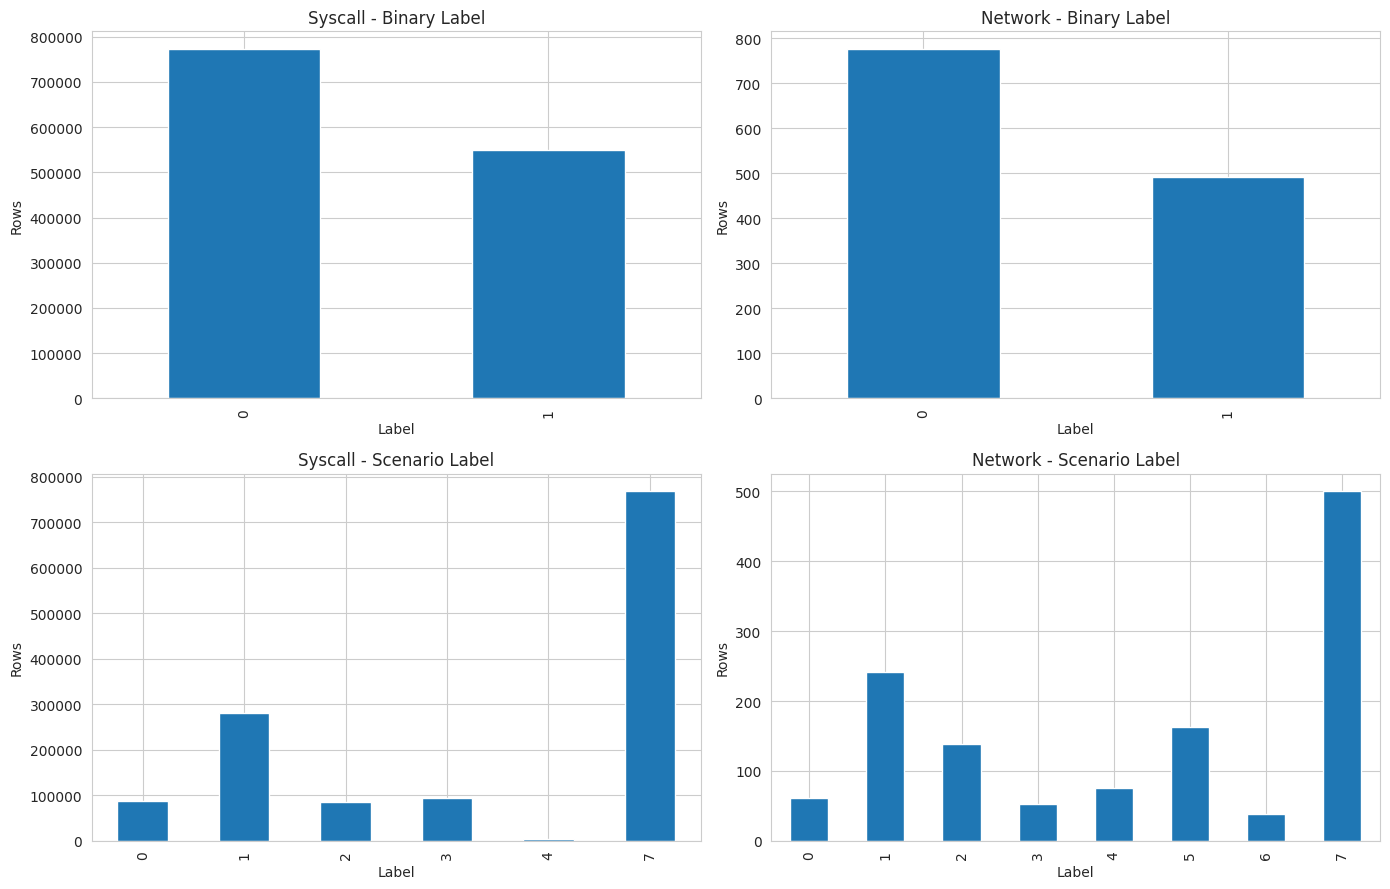

In [21]:
print("\n" + "="*50)
print("DISTRIBUSI TARGET")
print("="*50)
print("Syscall binary:", syscall_df["binary_label"].value_counts().sort_index().to_dict())
print("Network binary:", network_df["binary_label"].value_counts().sort_index().to_dict())
print("Syscall scenario:", syscall_df["scenario_label"].value_counts().sort_index().to_dict())
print("Network scenario:", network_df["scenario_label"].value_counts().sort_index().to_dict())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
syscall_df["binary_label"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Syscall - Binary Label")
network_df["binary_label"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Network - Binary Label")
syscall_df["scenario_label"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Syscall - Scenario Label")
network_df["scenario_label"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Network - Scenario Label")
for ax in axes.flatten():
    ax.set_xlabel("Label")
    ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

## Data Preparation

In [22]:
def prepare_xy(df, target_col):
    drop_cols = [col for col in METADATA_COLS + TARGET_COLS if col in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore")
    X = X.select_dtypes(include=[np.number]).fillna(0)
    y = df[target_col].astype(int)
    return X, y

X_syscall, y_syscall_binary = prepare_xy(syscall_df, "binary_label")
_, y_syscall_scenario = prepare_xy(syscall_df, "scenario_label")
X_network, y_network_binary = prepare_xy(network_df, "binary_label")
_, y_network_scenario = prepare_xy(network_df, "scenario_label")

print(f"Syscall features: {X_syscall.shape}")
print(f"Network features: {X_network.shape}")
print(f"Syscall feature columns: {X_syscall.columns.tolist()}")
print(f"Network feature columns: {X_network.columns.tolist()}")

Syscall features: (1321650, 5)
Network features: (1270, 20)
Syscall feature columns: ['n1', 'n2', 'n3', 'n4', 'n5']
Network feature columns: ['flow_count', 'unique_src_ports', 'unique_dst_ports', 'proto_TCP_count', 'proto_UDP_count', 'proto_OTHER_count', 'dir_EGRESS_count', 'dir_INGRESS_count', 'verdict_FORWARDED_count', 'verdict_TRACED_count', 'flag_SYN_count', 'flag_ACK_count', 'flag_FIN_count', 'flag_PSH_count', 'is_well_known_port_count', 'is_high_port_count', 'is_dns_port_count', 'is_http_port_count', 'is_db_port_count', 'is_mining_port_count']


In [23]:
def split_dataset(df, X, y, name):
    if "session_id" in df.columns and df["session_id"].nunique() > 1:
        group_col = "session_id"
    elif "pod_name" in df.columns and df["pod_name"].nunique() > 1:
        group_col = "pod_name"
    else:
        group_col = None

    if group_col:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(splitter.split(X, y, groups=df[group_col]))
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )

    print(f"{name} split group: {group_col or 'stratified row split'}")
    print(f"{name} - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"{name} train labels: {Counter(y_train)}")
    print(f"{name} test labels : {Counter(y_test)}")
    return X_train, X_test, y_train, y_test

X_train_sys_bin, X_test_sys_bin, y_train_sys_bin, y_test_sys_bin = split_dataset(
    syscall_df, X_syscall, y_syscall_binary, "Syscall Binary"
)
X_train_net_bin, X_test_net_bin, y_train_net_bin, y_test_net_bin = split_dataset(
    network_df, X_network, y_network_binary, "Network Binary"
)
X_train_sys, X_test_sys, y_train_sys, y_test_sys = split_dataset(
    syscall_df, X_syscall, y_syscall_scenario, "Syscall Scenario"
)
X_train_net, X_test_net, y_train_net, y_test_net = split_dataset(
    network_df, X_network, y_network_scenario, "Network Scenario"
)

Syscall Binary split group: session_id
Syscall Binary - Train: (971711, 5), Test: (349939, 5)
Syscall Binary train labels: Counter({0: 578647, 1: 393064})
Syscall Binary test labels : Counter({0: 194470, 1: 155469})
Network Binary split group: session_id
Network Binary - Train: (870, 20), Test: (400, 20)
Network Binary train labels: Counter({0: 526, 1: 344})
Network Binary test labels : Counter({0: 251, 1: 149})
Syscall Scenario split group: session_id
Syscall Scenario - Train: (971711, 5), Test: (349939, 5)
Syscall Scenario train labels: Counter({7: 575057, 1: 206728, 0: 68296, 2: 60548, 3: 57492, 4: 3590})
Syscall Scenario test labels : Counter({7: 193179, 1: 74625, 3: 35827, 2: 24894, 0: 20123, 4: 1291})
Network Scenario split group: session_id
Network Scenario - Train: (870, 20), Test: (400, 20)
Network Scenario train labels: Counter({7: 339, 1: 168, 5: 111, 2: 95, 4: 51, 0: 44, 3: 37, 6: 25})
Network Scenario test labels : Counter({7: 161, 1: 74, 5: 52, 2: 43, 4: 25, 0: 17, 3: 15,

## Class Balancing

In [24]:
def balance_training_data(X_train, y_train, name, max_growth=5, max_majority_ratio=0.5):
    counts = pd.Series(y_train).value_counts().sort_index()
    print(f"{name} - Before balancing: {counts.to_dict()}")

    if len(counts) < 2:
        print(f"{name} - Skipped: only one class present.")
        return X_train, y_train

    majority = int(counts.max())
    ratio_cap = max(1, int(majority * max_majority_ratio))
    sampling_strategy = {}
    for label, count in counts.items():
        count = int(count)
        target = min(majority, ratio_cap, count * max_growth)
        sampling_strategy[int(label)] = max(count, target)

    sampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_balanced, y_balanced = sampler.fit_resample(X_train, y_train)
    print(f"{name} - Sampling strategy: {sampling_strategy}")
    print(f"{name} - After balancing: {pd.Series(y_balanced).value_counts().sort_index().to_dict()}")
    return X_balanced, y_balanced

X_train_sys_bin_bal, y_train_sys_bin_bal = balance_training_data(X_train_sys_bin, y_train_sys_bin, "Syscall Binary")
X_train_net_bin_bal, y_train_net_bin_bal = balance_training_data(X_train_net_bin, y_train_net_bin, "Network Binary")
X_train_sys_balanced, y_train_sys_balanced = balance_training_data(X_train_sys, y_train_sys, "Syscall Scenario")
X_train_net_balanced, y_train_net_balanced = balance_training_data(X_train_net, y_train_net, "Network Scenario")

Syscall Binary - Before balancing: {0: 578647, 1: 393064}
Syscall Binary - Sampling strategy: {0: 578647, 1: 393064}
Syscall Binary - After balancing: {0: 578647, 1: 393064}
Network Binary - Before balancing: {0: 526, 1: 344}
Network Binary - Sampling strategy: {0: 526, 1: 344}
Network Binary - After balancing: {0: 526, 1: 344}
Syscall Scenario - Before balancing: {0: 68296, 1: 206728, 2: 60548, 3: 57492, 4: 3590, 7: 575057}
Syscall Scenario - Sampling strategy: {0: 287528, 1: 287528, 2: 287528, 3: 287460, 4: 17950, 7: 575057}
Syscall Scenario - After balancing: {0: 287528, 1: 287528, 2: 287528, 3: 287460, 4: 17950, 7: 575057}
Network Scenario - Before balancing: {0: 44, 1: 168, 2: 95, 3: 37, 4: 51, 5: 111, 6: 25, 7: 339}
Network Scenario - Sampling strategy: {0: 169, 1: 169, 2: 169, 3: 169, 4: 169, 5: 169, 6: 125, 7: 339}
Network Scenario - After balancing: {0: 169, 1: 169, 2: 169, 3: 169, 4: 169, 5: 169, 6: 125, 7: 339}


## Train Decision Tree Model

In [25]:
def make_dt():
    return DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion="gini",
        class_weight=None,
        random_state=42,
    )

dt_syscall_binary = make_dt()
dt_network_binary = make_dt()
dt_syscall = make_dt()
dt_network = make_dt()

print("Training binary syscall model...")
dt_syscall_binary.fit(X_train_sys_bin_bal, y_train_sys_bin_bal)
print("Training binary network model...")
dt_network_binary.fit(X_train_net_bin_bal, y_train_net_bin_bal)
print("Training scenario syscall model...")
dt_syscall.fit(X_train_sys_balanced, y_train_sys_balanced)
print("Training scenario network model...")
dt_network.fit(X_train_net_balanced, y_train_net_balanced)
print("All models trained")

Training binary syscall model...
Training binary network model...
Training scenario syscall model...
Training scenario network model...
All models trained


## Model Evaluation

In [26]:
def class_names_for_labels(labels, class_names):
    labels = sorted(pd.Series(labels).dropna().astype(int).unique())
    names = [class_names[i] if 0 <= i < len(class_names) else str(i) for i in labels]
    return labels, names

def evaluate_model(model, X_test, y_test, name, class_names):
    y_pred = model.predict(X_test)
    labels, names = class_names_for_labels(pd.concat([pd.Series(y_test), pd.Series(y_pred)]), class_names)

    print("="*50)
    print(name)
    print("="*50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=names,
        zero_division=0,
    ))
    return y_pred, labels, names

y_pred_sys_bin, sys_bin_labels, sys_bin_names = evaluate_model(
    dt_syscall_binary, X_test_sys_bin, y_test_sys_bin, "SYSCALL BINARY DETECTION", BINARY_CLASS_NAMES
)
y_pred_net_bin, net_bin_labels, net_bin_names = evaluate_model(
    dt_network_binary, X_test_net_bin, y_test_net_bin, "NETWORK BINARY DETECTION", BINARY_CLASS_NAMES
)
y_pred_sys, sys_labels, sys_names = evaluate_model(
    dt_syscall, X_test_sys, y_test_sys, "SYSCALL SCENARIO CLASSIFICATION", SCENARIO_CLASS_NAMES
)
y_pred_net, net_labels, net_names = evaluate_model(
    dt_network, X_test_net, y_test_net, "NETWORK SCENARIO CLASSIFICATION", SCENARIO_CLASS_NAMES
)

SYSCALL BINARY DETECTION
Accuracy: 0.9048
                       precision    recall  f1-score   support

               Benign       0.88      0.96      0.92    194470
Malicious/Compromised       0.94      0.84      0.89    155469

             accuracy                           0.90    349939
            macro avg       0.91      0.90      0.90    349939
         weighted avg       0.91      0.90      0.90    349939

NETWORK BINARY DETECTION
Accuracy: 0.9900
                       precision    recall  f1-score   support

               Benign       0.99      0.99      0.99       251
Malicious/Compromised       0.99      0.99      0.99       149

             accuracy                           0.99       400
            macro avg       0.99      0.99      0.99       400
         weighted avg       0.99      0.99      0.99       400

SYSCALL SCENARIO CLASSIFICATION
Accuracy: 0.8317
                   precision    recall  f1-score   support

           Botnet       0.86      0.90      0

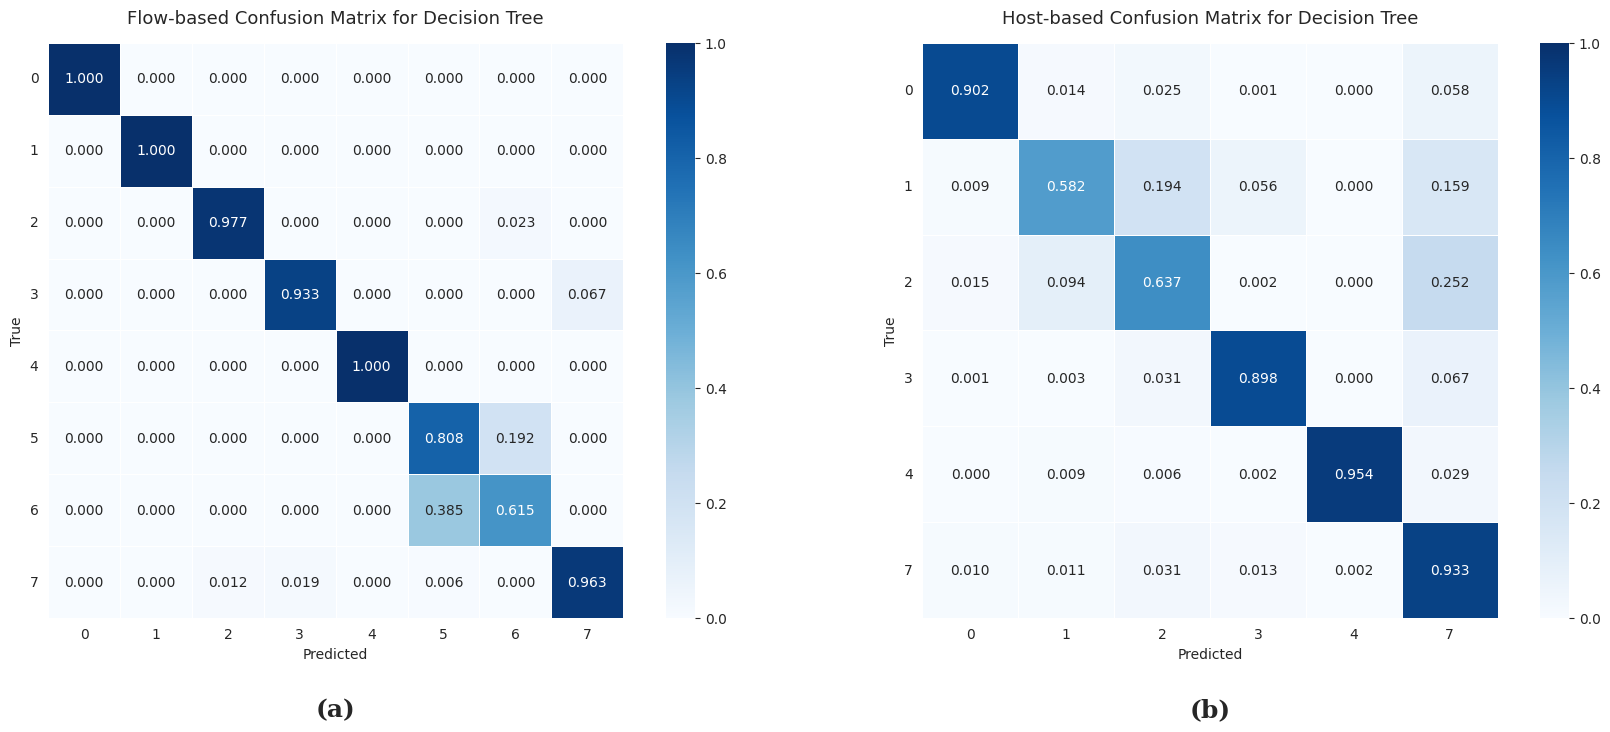

In [27]:
def normalized_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    return np.nan_to_num(cm, nan=0.0)

def plot_reference_confusion_matrices():
    flow_cm = normalized_confusion_matrix(y_test_net, y_pred_net, net_labels)
    host_cm = normalized_confusion_matrix(y_test_sys, y_pred_sys, sys_labels)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(
        flow_cm,
        ax=axes[0],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=net_labels,
        yticklabels=net_labels,
        linewidths=0.5,
        linecolor="white",
    )
    axes[0].set_title("Flow-based Confusion Matrix for Decision Tree", fontsize=13, pad=14)
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(
        host_cm,
        ax=axes[1],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=sys_labels,
        yticklabels=sys_labels,
        linewidths=0.5,
        linecolor="white",
    )
    axes[1].set_title("Host-based Confusion Matrix for Decision Tree", fontsize=13, pad=14)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)

    axes[0].text(
        0.5, -0.16, "(a)",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        family="serif",
    )
    axes[1].text(
        0.5, -0.16, "(b)",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        family="serif",
    )

    plt.tight_layout()
    plt.savefig("models/confusion_matrix_reference_style.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_reference_confusion_matrices()

## Figure 7-style Flow Distribution


In [ ]:
def first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def plot_figure7_style_flow_distribution(network_df):
    in_col = first_existing_column(
        network_df,
        [
            "IN_BYTES",
            "in_bytes",
            "input_bytes",
            "bytes_in",
            "dir_INGRESS_bytes",
            "dir_INGRESS_count",
        ],
    )
    out_col = first_existing_column(
        network_df,
        [
            "OUT_BYTES",
            "out_bytes",
            "output_bytes",
            "bytes_out",
            "dir_EGRESS_bytes",
            "dir_EGRESS_count",
        ],
    )

    if in_col is None or out_col is None:
        if {"dir_INGRESS_count", "dir_EGRESS_count"}.issubset(network_df.columns):
            in_col, out_col = "dir_INGRESS_count", "dir_EGRESS_count"
            title = "Comparison of In/Out Flow Count Distributions (log scale)"
        else:
            raise ValueError("No IN/OUT byte or ingress/egress count columns found.")
    else:
        title = "Comparison of In/Out Bytes Distributions (log scale)"

    plot_df = network_df.copy()
    target_col = "binary_label" if "binary_label" in plot_df.columns else "label"
    plot_df["traffic_type"] = np.where(plot_df[target_col] == 1, "Malicious/Compromised", "Benign")
    scenario_col = "scenario_label" if "scenario_label" in plot_df.columns else "label"
    plot_df["class_name"] = plot_df[scenario_col].map(lambda label: SCENARIO_CLASS_NAMES[int(label)])
    plot_df["_in_value"] = plot_df[in_col].clip(lower=0) + 1
    plot_df["_out_value"] = plot_df[out_col].clip(lower=0) + 1

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.scatterplot(
        data=plot_df,
        x="_out_value",
        y="_in_value",
        hue="traffic_type",
        style="traffic_type",
        size="traffic_type",
        sizes={"Benign": 45, "Malicious/Compromised": 65},
        alpha=0.75,
        ax=ax,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel(f"OUT ({out_col}) + 1")
    ax.set_ylabel(f"IN ({in_col}) + 1")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.35)
    ax.legend(title="Traffic Type")

    plt.tight_layout()
    plt.savefig("models/figure7_flow_distribution_style.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_figure7_style_flow_distribution(network_df)

## Figure 9-style Dominant Syscall Sequences


In [ ]:
def format_ngram(row):
    return "-".join(str(int(row[col])) for col in ["n1", "n2", "n3", "n4", "n5"])

def plot_figure9_style_syscall_sequences(syscall_df, top_n=5):
    required = {"n1", "n2", "n3", "n4", "n5"}
    missing = required - set(syscall_df.columns)
    if missing:
        raise ValueError(f"Missing syscall n-gram columns: {sorted(missing)}")

    scenario_col = "scenario_label" if "scenario_label" in syscall_df.columns else "label"
    if "binary_label" in syscall_df.columns:
        malicious_labels = sorted(syscall_df.loc[syscall_df["binary_label"] == 1, scenario_col].unique())
    else:
        malicious_labels = [label for label in sorted(syscall_df[scenario_col].unique()) if label <= 3]
    if not malicious_labels:
        raise ValueError("No malicious labels found in syscall dataset.")

    ncols = 2
    nrows = int(np.ceil(len(malicious_labels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, label in zip(axes, malicious_labels):
        subset = syscall_df[syscall_df[scenario_col] == label].copy()
        subset["sequence"] = subset.apply(format_ngram, axis=1)
        top = subset["sequence"].value_counts().head(top_n).sort_values()

        ax.barh(top.index, top.values, color="#2F6FAE")
        ax.set_title(f"{int(label)} {SCENARIO_CLASS_NAMES[int(label)]}", fontsize=12, pad=10)
        ax.set_xlabel("Frequency")
        ax.set_ylabel("5-gram sequence")
        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.35)

    for ax in axes[len(malicious_labels):]:
        ax.axis("off")

    fig.suptitle(
        "Frequency Distributions of Dominant System-call Sequences by Malicious/Compromised Scenario",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("models/figure9_syscall_sequences_style.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_figure9_style_syscall_sequences(syscall_df)

## Feature Importance

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_feature_importance(ax, model, columns, title):
    fi = (
        pd.DataFrame({"feature": columns, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    ax.barh(range(len(fi)), fi["importance"])
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels(fi["feature"])
    ax.set_title(title)
    ax.invert_yaxis()

plot_feature_importance(axes[0, 0], dt_syscall_binary, X_syscall.columns, "Top 15 Syscall Binary Features")
plot_feature_importance(axes[0, 1], dt_network_binary, X_network.columns, "Top 15 Network Binary Features")
plot_feature_importance(axes[1, 0], dt_syscall, X_syscall.columns, "Top 15 Syscall Scenario Features")
plot_feature_importance(axes[1, 1], dt_network, X_network.columns, "Top 15 Network Scenario Features")

plt.tight_layout()
plt.show()

## Visualisasi Decision Tree

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_tree(
    dt_syscall,
    max_depth=3,
    feature_names=X_syscall.columns,
    class_names=[SCENARIO_CLASS_NAMES[i] if 0 <= i < len(SCENARIO_CLASS_NAMES) else str(i) for i in sorted(dt_syscall.classes_)],
    filled=True,
    fontsize=8,
    ax=axes[0],
)
axes[0].set_title("Syscall Scenario Decision Tree (3 levels)", fontsize=14)

plot_tree(
    dt_network,
    max_depth=3,
    feature_names=X_network.columns,
    class_names=[SCENARIO_CLASS_NAMES[i] if 0 <= i < len(SCENARIO_CLASS_NAMES) else str(i) for i in sorted(dt_network.classes_)],
    filled=True,
    fontsize=8,
    ax=axes[1],
)
axes[1].set_title("Network Scenario Decision Tree (3 levels)", fontsize=14)

plt.tight_layout()
plt.show()

## Save Model

In [ ]:
Path("models").mkdir(exist_ok=True)

joblib.dump(dt_syscall_binary, "models/dt_syscall_binary_model.pkl")
joblib.dump(dt_network_binary, "models/dt_network_binary_model.pkl")
joblib.dump(dt_syscall, "models/dt_syscall_scenario_model.pkl")
joblib.dump(dt_network, "models/dt_network_scenario_model.pkl")

# Backward-compatible aliases for existing loader code.
joblib.dump(dt_syscall, "models/dt_syscall_model.pkl")
joblib.dump(dt_network, "models/dt_network_model.pkl")

joblib.dump(X_syscall.columns.tolist(), "models/feature_names_syscall.pkl")
joblib.dump(X_network.columns.tolist(), "models/feature_names_network.pkl")
joblib.dump(BINARY_CLASS_NAMES, "models/binary_class_names.pkl")
joblib.dump(SCENARIO_CLASS_NAMES, "models/scenario_class_names.pkl")

print("Binary syscall model: models/dt_syscall_binary_model.pkl")
print("Binary network model: models/dt_network_binary_model.pkl")
print("Scenario syscall model: models/dt_syscall_scenario_model.pkl")
print("Scenario network model: models/dt_network_scenario_model.pkl")
print("Feature names and class names saved")